In [1]:
!pip install seaborn
!pip install matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

🚀 Matrix-Based Pipeline Başlatılıyor...
✅ 480 model okundu.
🔋 Enerji verileri ekleniyor...
🧮 Matrix-Based Score hesaplanıyor...
💾 Rapor kaydedildi: /home/biolab/Projects/DesCARTes_wd/binder/RFantibody/CLDN_family/all_results/OTR_Matrix_Ranking.csv


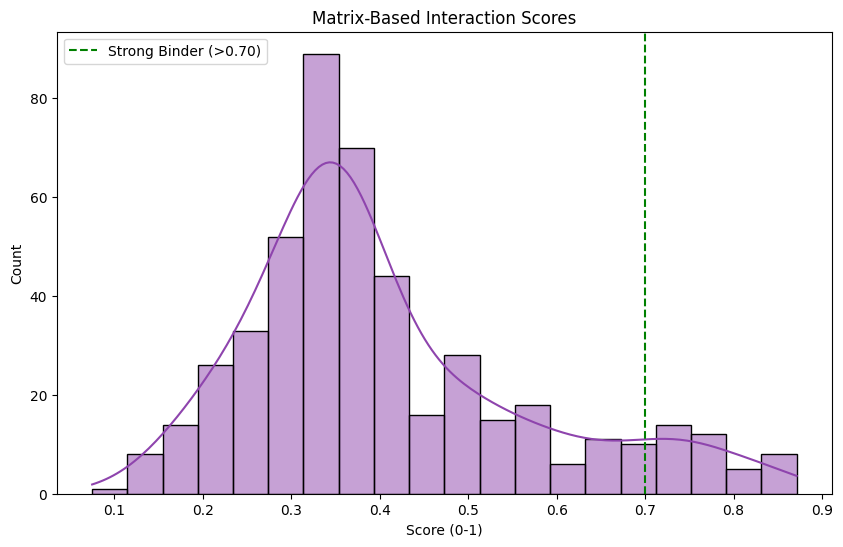


🏆 EN İYİ 5 SONUÇ (Detaylı Matrix Verisi ile):
        Sample_ID  Scientific_Score  Matrix_iPTM  Matrix_PAE  Affinity_dG  Fraction_Disordered
ab_16_cld15_human          0.871320        0.745        1.67      -13.525                 0.09
 ab_8_cld25_human          0.864151        0.730        2.45      -13.463                 0.08
 ab_10_cld8_human          0.862256        0.725        2.95      -12.750                 0.07
 ab_17_cld3_human          0.850951        0.685        2.35      -17.539                 0.08
ab_19_cld17_human          0.843210        0.710        2.67      -11.569                 0.07


In [ ]:
# @title 🧬 AF3 Matrix-Based Scoring Pipeline (v3.0 - No pLDDT)
# @markdown Bu hücreyi çalıştırın. JSON matrislerini kullanarak en hassas analizi yapar.

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob



# --- AYARLAR ---
CONFIG = {
    "root_dir": "/home/biolab/Projects/DesCARTes_wd/binder/RFantibody/CLDN_family/af3_output",
    "affinity_file": "/home/ozangocmen/RFantibody/CLDN_family_combinations/binding_affinity/off_target_prodigy.tsv",
    "output_csv": "/home/biolab/Projects/DesCARTes_wd/binder/RFantibody/CLDN_family/all_results/OTR_Matrix_Ranking.csv",

    # Yeni Ağırlıklar (pLDDT yok, Matrix verisi var)
    "weights": {
        "w_Matrix_iPTM": 0.40,   # Matristen gelen spesifik etkileşim
        "w_Matrix_PAE": 0.25,    # Matristen gelen PAE güveni
        "w_Affinity": 0.25,      # Prodigy Enerjisi
        "w_Global_pTM": 0.10     # Genel katlanma
    },

    # Enerji Sigmoid Ayarı (dG -> Skor)
    "sigmoid_midpoint": -9.0,
    "sigmoid_steepness": 1.0
}

# --- YENİ FONKSİYONLAR ---

def parse_af3_matrix_json(json_path):
    """
    User'ın sağladığı zengin JSON formatını işler.
    Matrislerden Antikor (Ch0, Ch1) vs Antijen (Ch2) etkileşimlerini çeker.
    """
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)

        # Temel Skalarlar
        ptm = data.get('ptm', 0)
        has_clash = data.get('has_clash', 0)
        frac_disordered = data.get('fraction_disordered', 0)
        ranking_score = data.get('ranking_score', 0)

        # MATRİS ANALİZİ (Kritik Bölüm)
        # Varsayım: 3 Zincir var. [0,1] = Antikor, [2] = Antijen.
        # Hedef: Chain 0-2 ve Chain 1-2 etkileşimleri.

        # 1. Interaction iPTM (Matristen)
        cp_iptm = data.get('chain_pair_iptm', [])
        interaction_iptm = 0
        if cp_iptm and len(cp_iptm) >= 3:
            # Antikor Zincir 1 (0) ile Antijen (2) arası
            val1 = cp_iptm[0][2]
            # Antikor Zincir 2 (1) ile Antijen (2) arası
            val2 = cp_iptm[1][2]
            # Ortalamasını al (veya max alabiliriz, ortalama daha güvenli)
            interaction_iptm = (val1 + val2) / 2.0
        else:
            # Matris bozuksa genel iptm'i kullan
            interaction_iptm = data.get('iptm', 0)

        # 2. Interface PAE (Matristen)
        # Düşük olması iyidir.
        cp_pae = data.get('chain_pair_pae_min', [])
        interface_pae = 15.0 # Kötü başlangıç
        if cp_pae and len(cp_pae) >= 3:
            val1 = cp_pae[0][2]
            val2 = cp_pae[1][2]
            # En düşük hatayı al (En iyi kenetlenme noktası)
            interface_pae = min(val1, val2)

        return {
            "pTM": ptm,
            "Has_Clash": has_clash,
            "Fraction_Disordered": frac_disordered,
            "Ranking_Score": ranking_score,
            "Matrix_iPTM": interaction_iptm,
            "Matrix_PAE": interface_pae
        }

    except Exception as e:
        print(f"JSON Parse Error: {e}")
        return None

def normalize_affinity_sigmoid(dG, mid_point, steepness):
    if dG > -4.0: return 0.0
    return 1.0 / (1.0 + np.exp(steepness * (dG - mid_point)))

def calculate_matrix_score(row, cfg):
    w = cfg['weights']

    # 1. PAE Normalizasyonu (Strict: <5 iyi, >12 kötü)
    raw_pae = row.get('Matrix_PAE', 15.0)
    # 5 Angstrom altı mükemmeldir (1.0), 12 üstü sıfırdır.
    # Lineer mapping: 5 -> 1, 12 -> 0
    norm_pae = (12.0 - raw_pae) / (12.0 - 5.0)
    norm_pae = np.clip(norm_pae, 0, 1)

    # 2. Affinity (Sigmoid)
    dG = row.get('Affinity_dG', 0)
    term_affinity = normalize_affinity_sigmoid(dG, cfg['sigmoid_midpoint'], cfg['sigmoid_steepness'])

    # 3. Disordered Penalty
    # Eğer %15'ten fazla disorder varsa her %1 için 0.01 puan kır.
    frac_dis = row.get('Fraction_Disordered', 0)
    penalty = 0
    if frac_dis > 0.15:
        penalty = (frac_dis - 0.15) * 1.0 # Örn: 0.25 disorder -> 0.10 ceza

    # --- SKOR HESABI ---
    score = (
        (w['w_Matrix_iPTM'] * row['Matrix_iPTM']) +
        (w['w_Global_pTM'] * row['pTM']) +
        (w['w_Matrix_PAE'] * norm_pae) +
        (w['w_Affinity'] * term_affinity)
    )

    # Cezaları uygula
    score = score - penalty

    # Clash varsa direkt 0 yap veya çok düşür
    if row.get('Has_Clash', 0) > 0:
        score = 0.0

    return max(0, score) # Negatife düşmesin

# --- ANA AKIŞ ---

print(f"🚀 Matrix-Based Pipeline Başlatılıyor...")

results = []
folders = glob(os.path.join(CONFIG["root_dir"], "*"))

for subdir in folders:
    if not os.path.isdir(subdir): continue
    sample_id = os.path.basename(subdir)

    # summary_confidences.json dosyasını bul
    summary_files = glob(os.path.join(subdir, "*summary_confidences.json"))
    if not summary_files: continue

    # Veriyi Çek
    metrics = parse_af3_matrix_json(summary_files[0])
    if metrics:
        metrics['Sample_ID'] = sample_id
        results.append(metrics)

df = pd.DataFrame(results)
print(f"✅ {len(df)} model okundu.")

# Enerji Verisi Ekleme (Prodigy)
if os.path.exists(CONFIG["affinity_file"]):
    print("🔋 Enerji verileri ekleniyor...")
    try:
        try:
            df_affinity = pd.read_csv(CONFIG["affinity_file"], sep=',')
            if 'dG' not in df_affinity.columns and 'Affinity_kcal-mol' not in df_affinity.columns:
                 df_affinity = pd.read_csv(CONFIG["affinity_file"], sep='\t')
        except:
            df_affinity = pd.read_csv(CONFIG["affinity_file"], sep='\t')

        cols = df_affinity.columns
        if 'Structure' in cols: df_affinity.rename(columns={'Structure': 'Sample_ID'}, inplace=True)
        if 'dG' in cols: df_affinity.rename(columns={'dG': 'Affinity_dG'}, inplace=True)
        if 'Affinity_kcal-mol' in cols: df_affinity.rename(columns={'Affinity_kcal-mol': 'Affinity_dG'}, inplace=True)

        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].astype(str).str.replace(r'_model.*', '', regex=True)

        df = pd.merge(df, df_affinity[['Sample_ID', 'Affinity_dG']], on='Sample_ID', how='left')
        df['Affinity_dG'] = df['Affinity_dG'].fillna(0)
    except Exception as e:
        print(f"Enerji hatası: {e}")
        df['Affinity_dG'] = 0
else:
    df['Affinity_dG'] = 0

# Skorlama
print("🧮 Matrix-Based Score hesaplanıyor...")
df['Scientific_Score'] = df.apply(lambda row: calculate_matrix_score(row, CONFIG), axis=1)

# Sıralama ve Kayıt
df_sorted = df.sort_values(by="Scientific_Score", ascending=False)
df_sorted.to_csv(CONFIG["output_csv"], index=False)
print(f"💾 Rapor kaydedildi: {CONFIG['output_csv']}")

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.histplot(df_sorted['Scientific_Score'], bins=20, kde=True, color='#8e44ad')
plt.axvline(0.70, color='green', linestyle='--', label='Strong Binder (>0.70)')
plt.title("Matrix-Based Interaction Scores")
plt.xlabel("Score (0-1)")
plt.legend()
plt.show()

print("\n🏆 EN İYİ 5 SONUÇ (Detaylı Matrix Verisi ile):")
cols = ['Sample_ID', 'Scientific_Score', 'Matrix_iPTM', 'Matrix_PAE', 'Affinity_dG', 'Fraction_Disordered']
print(df_sorted[cols].head(5).to_string(index=False))

In [3]:
import numpy as np
print(np.__version__)

2.0.2


In [4]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [5]:
import pandas as pd
print(pd.__version__)

2.3.3


🚀 Matrix-Based Pipeline Başlatılıyor...
📁 Toplam 936 klasör taranıyor...
✅ scfv_93_7_vs_cld19_human: Veriler okundu
✅ scfv_86_0_vs_cld22_human: Veriler okundu
✅ scfv_93_7_vs_cld16_human: Veriler okundu
✅ scfv_0_2_vs_cld17_human: Veriler okundu
✅ scfv_85_8_vs_cld24_human: Veriler okundu
✅ scfv_86_1_vs_cld18_2_human: Veriler okundu
✅ scfv_48_2_vs_cld1_human: Veriler okundu
✅ scfv_77_1_vs_cld14_human: Veriler okundu
✅ scfv_73_2_vs_cld14_human: Veriler okundu
✅ scfv_66_2_vs_cld14_human: Veriler okundu
✅ scfv_50_2_vs_cld17_human: Veriler okundu
✅ scfv_55_6_vs_cld12_human: Veriler okundu
✅ scfv_66_2_vs_cld3_human: Veriler okundu
✅ scfv_0_4_vs_cld34_human: Veriler okundu
✅ scfv_86_8_vs_cld17_human: Veriler okundu
✅ scfv_25_2_vs_cld18_2_human: Veriler okundu
✅ scfv_50_2_vs_cld18_human: Veriler okundu
✅ scfv_39_0_vs_cld10_human: Veriler okundu
✅ scfv_94_1_vs_cld10_human: Veriler okundu
✅ scfv_0_8_vs_cld5_human: Veriler okundu
✅ scfv_55_6_vs_cld19_human: Veriler okundu
✅ scfv_77_6_vs_cld14_human

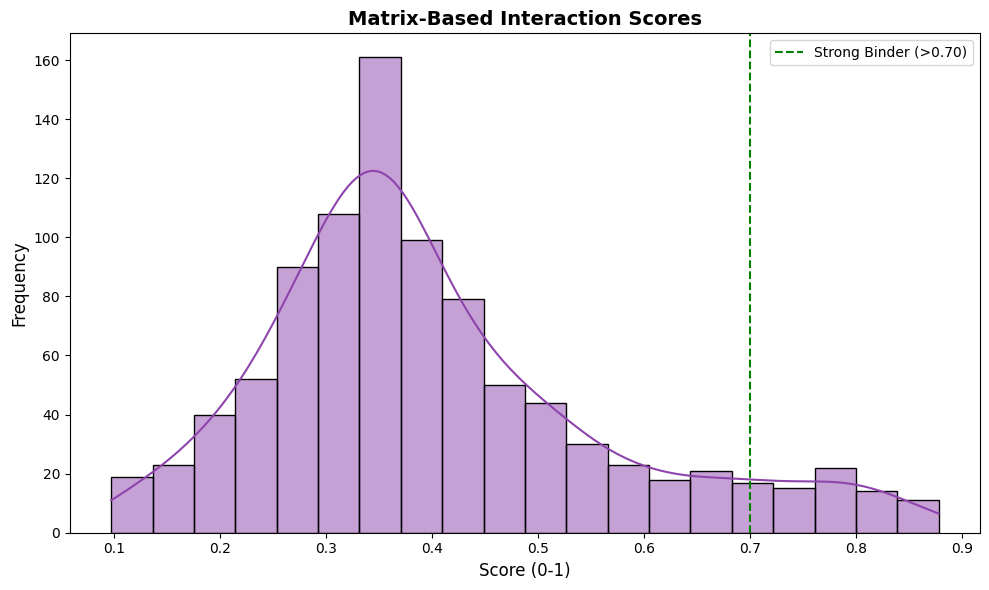


📊 İSTATİSTİKSEL ÖZET
Toplam Model Sayısı: 936
Ortalama Score: 0.401
Medyan Score: 0.364
Std Sapma: 0.163
Strong Binder (>0.70): 73 model
Moderate Binder (0.50-0.70): 128 model
Weak Binder (<0.50): 735 model

🏆 EN İYİ 10 SONUÇ (Detaylı Matrix Verisi ile)
               Sample_ID  Scientific_Score  Matrix_iPTM  Matrix_PAE  Affinity_dG  pTM  Fraction_Disordered
 scfv_55_9_vs_cld8_human          0.877808        0.785        1.61      -11.670 0.80                 0.07
scfv_39_1_vs_cld34_human          0.876917        0.750        2.25      -13.383 0.80                 0.03
scfv_86_8_vs_cld15_human          0.873871        0.750        1.91      -13.368 0.77                 0.09
scfv_48_2_vs_cld16_human          0.868463        0.740        2.70      -13.244 0.76                 0.09
scfv_48_1_vs_cld15_human          0.866345        0.760        2.09      -11.706 0.78                 0.09
scfv_83_1_vs_cld16_human          0.864108        0.760        1.72      -11.690 0.76                 0

In [2]:
# @title 🧬 AF3 Matrix-Based Scoring Pipeline (v3.1 - Corrected Paths & CLD18_2)
# @markdown Bu hücreyi çalıştırın. JSON matrislerini kullanarak en hassas analizi yapar.

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# --- AYARLAR ---
CONFIG = {
    "root_dir": "/home/ozangocmen/RFantibody/CLDN_family_combinations/outputs",
    "affinity_file": "/home/ozangocmen/RFantibody/CLDN_family_combinations/binding_affinity/off_target_prodigy.tsv",
    "output_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_Matrix_Ranking.csv",
    
    # Yeni Ağırlıklar (pLDDT yok, Matrix verisi var)
    "weights": {
        "w_Matrix_iPTM": 0.40,    # Matristen gelen spesifik etkileşim
        "w_Matrix_PAE": 0.25,     # Matristen gelen PAE güveni
        "w_Affinity": 0.25,       # Prodigy Enerjisi
        "w_Global_pTM": 0.10      # Genel katlanma
    },
    
    # Enerji Sigmoid Ayarı (dG -> Skor)
    "sigmoid_midpoint": -9.0,
    "sigmoid_steepness": 1.0
}

# --- YENİ FONKSİYONLAR ---

def parse_af3_matrix_json(json_path):
    """
    User'ın sağladığı zengin JSON formatını işler.
    Matrislerden Antikor (Ch0, Ch1) vs Antijen (Ch2) etkileşimlerini çeker.
    """
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Temel Skalarlar
        ptm = data.get('ptm', 0)
        has_clash = data.get('has_clash', 0)
        frac_disordered = data.get('fraction_disordered', 0)
        ranking_score = data.get('ranking_score', 0)
        
        # MATRİS ANALİZİ (Kritik Bölüm)
        # Varsayım: 3 Zincir var. [0,1] = Antikor, [2] = Antijen.
        # Hedef: Chain 0-2 ve Chain 1-2 etkileşimleri.
        
        # 1. Interaction iPTM (Matristen)
        cp_iptm = data.get('chain_pair_iptm', [])
        interaction_iptm = 0
        
        if cp_iptm and len(cp_iptm) >= 3:
            # Antikor Zincir 1 (0) ile Antijen (2) arası
            val1 = cp_iptm[0][2]
            # Antikor Zincir 2 (1) ile Antijen (2) arası
            val2 = cp_iptm[1][2]
            # Ortalamasını al (veya max alabiliriz, ortalama daha güvenli)
            interaction_iptm = (val1 + val2) / 2.0
        else:
            # Matris bozuksa genel iptm'i kullan
            interaction_iptm = data.get('iptm', 0)
        
        # 2. Interface PAE (Matristen)
        # Düşük olması iyidir.
        cp_pae = data.get('chain_pair_pae_min', [])
        interface_pae = 15.0  # Kötü başlangıç
        
        if cp_pae and len(cp_pae) >= 3:
            val1 = cp_pae[0][2]
            val2 = cp_pae[1][2]
            # En düşük hatayı al (En iyi kenetlenme noktası)
            interface_pae = min(val1, val2)
        
        return {
            "pTM": ptm,
            "Has_Clash": has_clash,
            "Fraction_Disordered": frac_disordered,
            "Ranking_Score": ranking_score,
            "Matrix_iPTM": interaction_iptm,
            "Matrix_PAE": interface_pae
        }
        
    except Exception as e:
        print(f"JSON Parse Error for {json_path}: {e}")
        return None


def normalize_affinity_sigmoid(dG, mid_point, steepness):
    """Enerji değerini sigmoid ile 0-1 arasına normalize eder"""
    if dG > -4.0:
        return 0.0
    return 1.0 / (1.0 + np.exp(steepness * (dG - mid_point)))


def calculate_matrix_score(row, cfg):
    """Matrix tabanlı skor hesaplama"""
    w = cfg['weights']
    
    # 1. PAE Normalizasyonu (Strict: <5 iyi, >12 kötü)
    raw_pae = row.get('Matrix_PAE', 15.0)
    # 5 Angstrom altı mükemmeldir (1.0), 12 üstü sıfırdır.
    # Lineer mapping: 5 -> 1, 12 -> 0
    norm_pae = (12.0 - raw_pae) / (12.0 - 5.0)
    norm_pae = np.clip(norm_pae, 0, 1)
    
    # 2. Affinity (Sigmoid)
    dG = row.get('Affinity_dG', 0)
    term_affinity = normalize_affinity_sigmoid(dG, cfg['sigmoid_midpoint'], cfg['sigmoid_steepness'])
    
    # 3. Disordered Penalty
    # Eğer %15'ten fazla disorder varsa her %1 için 0.01 puan kır.
    frac_dis = row.get('Fraction_Disordered', 0)
    penalty = 0
    if frac_dis > 0.15:
        penalty = (frac_dis - 0.15) * 1.0  # Örn: 0.25 disorder -> 0.10 ceza
    
    # --- SKOR HESABI ---
    score = (
        (w['w_Matrix_iPTM'] * row['Matrix_iPTM']) +
        (w['w_Global_pTM'] * row['pTM']) +
        (w['w_Matrix_PAE'] * norm_pae) +
        (w['w_Affinity'] * term_affinity)
    )
    
    # Cezaları uygula
    score = score - penalty
    
    # Clash varsa direkt 0 yap veya çok düşür
    if row.get('Has_Clash', 0) > 0:
        score = 0.0
    
    return max(0, score)  # Negatife düşmesin


# --- ANA AKIŞ ---
print(f"🚀 Matrix-Based Pipeline Başlatılıyor...")

results = []
folders = glob(os.path.join(CONFIG["root_dir"], "*"))

print(f"📁 Toplam {len(folders)} klasör taranıyor...")

for subdir in folders:
    if not os.path.isdir(subdir):
        continue
    
    sample_id = os.path.basename(subdir)
    
    # summary_confidences.json dosyasını bul
    summary_files = glob(os.path.join(subdir, "*summary_confidences.json"))
    
    if not summary_files:
        print(f"⚠️  {sample_id}: summary_confidences.json bulunamadı")
        continue
    
    # Veriyi Çek
    metrics = parse_af3_matrix_json(summary_files[0])
    
    if metrics:
        metrics['Sample_ID'] = sample_id
        results.append(metrics)
        print(f"✅ {sample_id}: Veriler okundu")

df = pd.DataFrame(results)
print(f"\n✅ Toplam {len(df)} model başarıyla okundu.")

if len(df) == 0:
    print("❌ HATA: Hiç veri okunamadı! Dosya yollarını kontrol edin.")
    exit(1)

# Enerji Verisi Ekleme (Prodigy)
if os.path.exists(CONFIG["affinity_file"]):
    print("\n🔋 Enerji verileri ekleniyor...")
    try:
        # TSV dosyasını oku
        df_affinity = pd.read_csv(CONFIG["affinity_file"], sep='\t')
        
        # Sütun isimlerini kontrol et ve düzelt
        print(f"   Affinity dosyası sütunları: {list(df_affinity.columns)}")
        
        if 'Structure' in df_affinity.columns:
            df_affinity.rename(columns={'Structure': 'Sample_ID'}, inplace=True)
        
        if 'Affinity_kcal-mol' in df_affinity.columns:
            df_affinity.rename(columns={'Affinity_kcal-mol': 'Affinity_dG'}, inplace=True)
        elif 'dG' in df_affinity.columns:
            df_affinity.rename(columns={'dG': 'Affinity_dG'}, inplace=True)
        
        # Model suffix'ini kaldır (_model0, _model_model0 gibi)
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].astype(str).str.replace(r'_model.*', '', regex=True)
        
        # CLD18_2 özel durumunu işle
        # Hem "cld18_2" hem "cld18_2_human" gibi varyantları normalize et
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].str.replace('cld18_2_human', 'cld18_2', regex=False)
        
        print(f"   Affinity dosyasında {len(df_affinity)} kayıt var")
        print(f"   İlk 5 Sample_ID: {df_affinity['Sample_ID'].head().tolist()}")
        
        # Merge işlemi
        df = pd.merge(df, df_affinity[['Sample_ID', 'Affinity_dG']], on='Sample_ID', how='left')
        
        # Eksik değerleri 0 ile doldur
        df['Affinity_dG'] = df['Affinity_dG'].fillna(0)
        
        matched = df['Affinity_dG'].ne(0).sum()
        print(f"   ✅ {matched}/{len(df)} model ile affinity verisi eşleşti")
        
        if matched < len(df):
            print(f"   ⚠️  {len(df) - matched} model için affinity verisi bulunamadı")
            print(f"   Örnek eşleşmeyen Sample_ID'ler:")
            unmatched = df[df['Affinity_dG'] == 0]['Sample_ID'].head(5).tolist()
            for uid in unmatched:
                print(f"      - {uid}")
        
    except Exception as e:
        print(f"❌ Enerji verisi yükleme hatası: {e}")
        import traceback
        traceback.print_exc()
        df['Affinity_dG'] = 0
else:
    print(f"⚠️  Affinity dosyası bulunamadı: {CONFIG['affinity_file']}")
    df['Affinity_dG'] = 0

# Skorlama
print("\n🧮 Matrix-Based Score hesaplanıyor...")
df['Scientific_Score'] = df.apply(lambda row: calculate_matrix_score(row, CONFIG), axis=1)

# Sıralama ve Kayıt
df_sorted = df.sort_values(by="Scientific_Score", ascending=False)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["output_csv"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Output dizini oluşturuldu: {output_dir}")

df_sorted.to_csv(CONFIG["output_csv"], index=False)
print(f"\n💾 Rapor kaydedildi: {CONFIG['output_csv']}")

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.histplot(df_sorted['Scientific_Score'], bins=20, kde=True, color='#8e44ad')
plt.axvline(0.70, color='green', linestyle='--', label='Strong Binder (>0.70)')
plt.title("Matrix-Based Interaction Scores", fontsize=14, fontweight='bold')
plt.xlabel("Score (0-1)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(CONFIG["output_csv"].replace('.csv', '_histogram.png'), dpi=300)
print(f"📊 Histogram kaydedildi: {CONFIG['output_csv'].replace('.csv', '_histogram.png')}")
plt.show()

# Detaylı İstatistikler
print("\n" + "="*80)
print("📊 İSTATİSTİKSEL ÖZET")
print("="*80)
print(f"Toplam Model Sayısı: {len(df_sorted)}")
print(f"Ortalama Score: {df_sorted['Scientific_Score'].mean():.3f}")
print(f"Medyan Score: {df_sorted['Scientific_Score'].median():.3f}")
print(f"Std Sapma: {df_sorted['Scientific_Score'].std():.3f}")
print(f"Strong Binder (>0.70): {(df_sorted['Scientific_Score'] > 0.70).sum()} model")
print(f"Moderate Binder (0.50-0.70): {((df_sorted['Scientific_Score'] >= 0.50) & (df_sorted['Scientific_Score'] <= 0.70)).sum()} model")
print(f"Weak Binder (<0.50): {(df_sorted['Scientific_Score'] < 0.50).sum()} model")

# En İyi 10 Sonuç
print("\n" + "="*80)
print("🏆 EN İYİ 10 SONUÇ (Detaylı Matrix Verisi ile)")
print("="*80)
cols = ['Sample_ID', 'Scientific_Score', 'Matrix_iPTM', 'Matrix_PAE', 'Affinity_dG', 'pTM', 'Fraction_Disordered']
print(df_sorted[cols].head(10).to_string(index=False))

# En Kötü 5 Sonuç (Kontrol için)
print("\n" + "="*80)
print("⚠️  EN DÜŞÜK 5 SONUÇ (Kontrol için)")
print("="*80)
print(df_sorted[cols].tail(5).to_string(index=False))

# CLD18_2 özel kontrol
cld18_2_models = df_sorted[df_sorted['Sample_ID'].str.contains('cld18_2', case=False)]
if len(cld18_2_models) > 0:
    print("\n" + "="*80)
    print("🔍 CLD18_2 MODELLER")
    print("="*80)
    print(cld18_2_models[cols].to_string(index=False))
else:
    print("\n⚠️  CLD18_2 modeli bulunamadı!")

print("\n✅ Pipeline tamamlandı!")

## test0 CLDN18_2 afinite değerleri gelmemiş

🚀 Matrix-Based Pipeline Başlatılıyor...
📁 Toplam 936 klasör taranıyor...
✅ scfv_93_7_vs_cld19_human: Veriler okundu
✅ scfv_86_0_vs_cld22_human: Veriler okundu
✅ scfv_93_7_vs_cld16_human: Veriler okundu
✅ scfv_0_2_vs_cld17_human: Veriler okundu
✅ scfv_85_8_vs_cld24_human: Veriler okundu
✅ scfv_86_1_vs_cld18_2_human: Veriler okundu
✅ scfv_48_2_vs_cld1_human: Veriler okundu
✅ scfv_77_1_vs_cld14_human: Veriler okundu
✅ scfv_73_2_vs_cld14_human: Veriler okundu
✅ scfv_66_2_vs_cld14_human: Veriler okundu
✅ scfv_50_2_vs_cld17_human: Veriler okundu
✅ scfv_55_6_vs_cld12_human: Veriler okundu
✅ scfv_66_2_vs_cld3_human: Veriler okundu
✅ scfv_0_4_vs_cld34_human: Veriler okundu
✅ scfv_86_8_vs_cld17_human: Veriler okundu
✅ scfv_25_2_vs_cld18_2_human: Veriler okundu
✅ scfv_50_2_vs_cld18_human: Veriler okundu
✅ scfv_39_0_vs_cld10_human: Veriler okundu
✅ scfv_94_1_vs_cld10_human: Veriler okundu
✅ scfv_0_8_vs_cld5_human: Veriler okundu
✅ scfv_55_6_vs_cld19_human: Veriler okundu
✅ scfv_77_6_vs_cld14_human

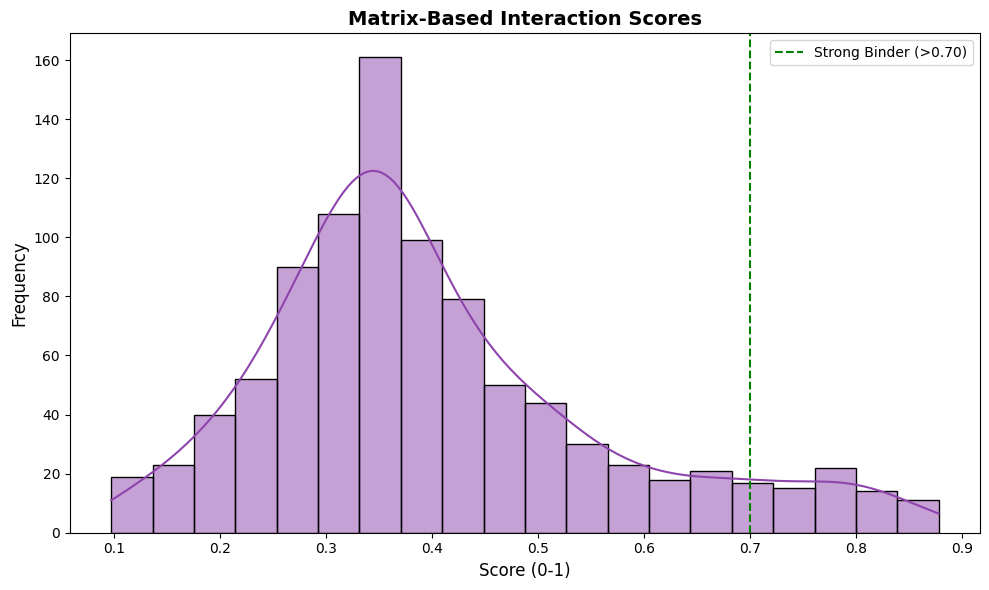


📊 İSTATİSTİKSEL ÖZET
Toplam Model Sayısı: 936
Ortalama Score: 0.401
Medyan Score: 0.364
Std Sapma: 0.163
Strong Binder (>0.70): 73 model
Moderate Binder (0.50-0.70): 128 model
Weak Binder (<0.50): 735 model

🏆 EN İYİ 10 SONUÇ (Detaylı Matrix Verisi ile)
               Sample_ID  Scientific_Score  Matrix_iPTM  Matrix_PAE  Affinity_dG  pTM  Fraction_Disordered
 scfv_55_9_vs_cld8_human          0.877808        0.785        1.61      -11.670 0.80                 0.07
scfv_39_1_vs_cld34_human          0.876917        0.750        2.25      -13.383 0.80                 0.03
scfv_86_8_vs_cld15_human          0.873871        0.750        1.91      -13.368 0.77                 0.09
scfv_48_2_vs_cld16_human          0.868463        0.740        2.70      -13.244 0.76                 0.09
scfv_48_1_vs_cld15_human          0.866345        0.760        2.09      -11.706 0.78                 0.09
scfv_83_1_vs_cld16_human          0.864108        0.760        1.72      -11.690 0.76                 0

In [3]:
# @title 🧬 AF3 Matrix-Based Scoring Pipeline (v3.1 - Corrected Paths & CLD18_2)
# @markdown Bu hücreyi çalıştırın. JSON matrislerini kullanarak en hassas analizi yapar.

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# --- AYARLAR ---
CONFIG = {
    "root_dir": "/home/ozangocmen/RFantibody/CLDN_family_combinations/outputs",
    "affinity_file": "/home/ozangocmen/RFantibody/CLDN_family_combinations/binding_affinity/off_target_prodigy.tsv",
    "output_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_Matrix_Ranking.csv",
    
    # Yeni Ağırlıklar (pLDDT yok, Matrix verisi var)
    "weights": {
        "w_Matrix_iPTM": 0.40,    # Matristen gelen spesifik etkileşim
        "w_Matrix_PAE": 0.25,     # Matristen gelen PAE güveni
        "w_Affinity": 0.25,       # Prodigy Enerjisi
        "w_Global_pTM": 0.10      # Genel katlanma
    },
    
    # Enerji Sigmoid Ayarı (dG -> Skor)
    "sigmoid_midpoint": -9.0,
    "sigmoid_steepness": 1.0
}

# --- YENİ FONKSİYONLAR ---

def parse_af3_matrix_json(json_path):
    """
    User'ın sağladığı zengin JSON formatını işler.
    Matrislerden Antikor (Ch0, Ch1) vs Antijen (Ch2) etkileşimlerini çeker.
    """
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Temel Skalarlar
        ptm = data.get('ptm', 0)
        has_clash = data.get('has_clash', 0)
        frac_disordered = data.get('fraction_disordered', 0)
        ranking_score = data.get('ranking_score', 0)
        
        # MATRİS ANALİZİ (Kritik Bölüm)
        # Varsayım: 3 Zincir var. [0,1] = Antikor, [2] = Antijen.
        # Hedef: Chain 0-2 ve Chain 1-2 etkileşimleri.
        
        # 1. Interaction iPTM (Matristen)
        cp_iptm = data.get('chain_pair_iptm', [])
        interaction_iptm = 0
        
        if cp_iptm and len(cp_iptm) >= 3:
            # Antikor Zincir 1 (0) ile Antijen (2) arası
            val1 = cp_iptm[0][2]
            # Antikor Zincir 2 (1) ile Antijen (2) arası
            val2 = cp_iptm[1][2]
            # Ortalamasını al (veya max alabiliriz, ortalama daha güvenli)
            interaction_iptm = (val1 + val2) / 2.0
        else:
            # Matris bozuksa genel iptm'i kullan
            interaction_iptm = data.get('iptm', 0)
        
        # 2. Interface PAE (Matristen)
        # Düşük olması iyidir.
        cp_pae = data.get('chain_pair_pae_min', [])
        interface_pae = 15.0  # Kötü başlangıç
        
        if cp_pae and len(cp_pae) >= 3:
            val1 = cp_pae[0][2]
            val2 = cp_pae[1][2]
            # En düşük hatayı al (En iyi kenetlenme noktası)
            interface_pae = min(val1, val2)
        
        return {
            "pTM": ptm,
            "Has_Clash": has_clash,
            "Fraction_Disordered": frac_disordered,
            "Ranking_Score": ranking_score,
            "Matrix_iPTM": interaction_iptm,
            "Matrix_PAE": interface_pae
        }
        
    except Exception as e:
        print(f"JSON Parse Error for {json_path}: {e}")
        return None


def normalize_affinity_sigmoid(dG, mid_point, steepness):
    """Enerji değerini sigmoid ile 0-1 arasına normalize eder"""
    if dG > -4.0:
        return 0.0
    return 1.0 / (1.0 + np.exp(steepness * (dG - mid_point)))


def calculate_matrix_score(row, cfg):
    """Matrix tabanlı skor hesaplama"""
    w = cfg['weights']
    
    # 1. PAE Normalizasyonu (Strict: <5 iyi, >12 kötü)
    raw_pae = row.get('Matrix_PAE', 15.0)
    # 5 Angstrom altı mükemmeldir (1.0), 12 üstü sıfırdır.
    # Lineer mapping: 5 -> 1, 12 -> 0
    norm_pae = (12.0 - raw_pae) / (12.0 - 5.0)
    norm_pae = np.clip(norm_pae, 0, 1)
    
    # 2. Affinity (Sigmoid)
    dG = row.get('Affinity_dG', 0)
    term_affinity = normalize_affinity_sigmoid(dG, cfg['sigmoid_midpoint'], cfg['sigmoid_steepness'])
    
    # 3. Disordered Penalty
    # Eğer %15'ten fazla disorder varsa her %1 için 0.01 puan kır.
    frac_dis = row.get('Fraction_Disordered', 0)
    penalty = 0
    if frac_dis > 0.15:
        penalty = (frac_dis - 0.15) * 1.0  # Örn: 0.25 disorder -> 0.10 ceza
    
    # --- SKOR HESABI ---
    score = (
        (w['w_Matrix_iPTM'] * row['Matrix_iPTM']) +
        (w['w_Global_pTM'] * row['pTM']) +
        (w['w_Matrix_PAE'] * norm_pae) +
        (w['w_Affinity'] * term_affinity)
    )
    
    # Cezaları uygula
    score = score - penalty
    
    # Clash varsa direkt 0 yap veya çok düşür
    if row.get('Has_Clash', 0) > 0:
        score = 0.0
    
    return max(0, score)  # Negatife düşmesin


# --- ANA AKIŞ ---
print(f"🚀 Matrix-Based Pipeline Başlatılıyor...")

results = []
folders = glob(os.path.join(CONFIG["root_dir"], "*"))

print(f"📁 Toplam {len(folders)} klasör taranıyor...")

for subdir in folders:
    if not os.path.isdir(subdir):
        continue
    
    sample_id = os.path.basename(subdir)
    
    # summary_confidences.json dosyasını bul
    summary_files = glob(os.path.join(subdir, "*summary_confidences.json"))
    
    if not summary_files:
        print(f"⚠️  {sample_id}: summary_confidences.json bulunamadı")
        continue
    
    # Veriyi Çek
    metrics = parse_af3_matrix_json(summary_files[0])
    
    if metrics:
        metrics['Sample_ID'] = sample_id
        results.append(metrics)
        print(f"✅ {sample_id}: Veriler okundu")

df = pd.DataFrame(results)
print(f"\n✅ Toplam {len(df)} model başarıyla okundu.")

if len(df) == 0:
    print("❌ HATA: Hiç veri okunamadı! Dosya yollarını kontrol edin.")
    exit(1)

# Enerji Verisi Ekleme (Prodigy)
if os.path.exists(CONFIG["affinity_file"]):
    print("\n🔋 Enerji verileri ekleniyor...")
    try:
        # TSV dosyasını oku - boşlukları kaldır
        df_affinity = pd.read_csv(CONFIG["affinity_file"], sep='\t')
        
        # Sütun isimlerini temizle (boşlukları kaldır)
        df_affinity.columns = df_affinity.columns.str.strip()
        
        print(f"   Affinity dosyası sütunları: {list(df_affinity.columns)}")
        print(f"   İlk 3 satır:\n{df_affinity.head(3)}")
        
        # Sütun isimlerini standardize et
        if 'Structure' in df_affinity.columns:
            df_affinity.rename(columns={'Structure': 'Sample_ID'}, inplace=True)
        
        if 'Affinity_kcal-mol' in df_affinity.columns:
            df_affinity.rename(columns={'Affinity_kcal-mol': 'Affinity_dG'}, inplace=True)
        elif 'dG' in df_affinity.columns:
            df_affinity.rename(columns={'dG': 'Affinity_dG'}, inplace=True)
        
        # Affinity değerlerindeki boşlukları temizle ve float'a çevir
        if 'Affinity_dG' in df_affinity.columns:
            df_affinity['Affinity_dG'] = df_affinity['Affinity_dG'].astype(str).str.strip().astype(float)
        
        # Sample ID'leri temizle ve normalize et
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].astype(str).str.strip()
        
        # Model suffix'ini kaldır (_model_model0 veya _model0)
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].str.replace(r'_model.*', '', regex=True)
        
        # CLD18_2 özel durumunu işle
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].str.replace('cld18_2_human', 'cld18_2', regex=False)
        
        print(f"\n   Affinity dosyasında {len(df_affinity)} kayıt var")
        print(f"   İlk 5 Sample_ID (normalized):")
        for sid in df_affinity['Sample_ID'].head().tolist():
            print(f"      - {sid}")
        
        print(f"\n   İlk 5 Sample_ID (df):")
        for sid in df['Sample_ID'].head().tolist():
            print(f"      - {sid}")
        
        # Merge işlemi
        df = pd.merge(df, df_affinity[['Sample_ID', 'Affinity_dG']], on='Sample_ID', how='left')
        
        # Eksik değerleri 0 ile doldur
        df['Affinity_dG'] = df['Affinity_dG'].fillna(0)
        
        matched = df['Affinity_dG'].ne(0).sum()
        print(f"\n   ✅ {matched}/{len(df)} model ile affinity verisi eşleşti")
        
        if matched < len(df):
            print(f"   ⚠️  {len(df) - matched} model için affinity verisi bulunamadı")
            print(f"\n   Örnek eşleşmeyen Sample_ID'ler:")
            unmatched = df[df['Affinity_dG'] == 0]['Sample_ID'].head(10).tolist()
            for uid in unmatched:
                print(f"      - {uid}")
            
            # Affinity dosyasında olup df'de olmayan kayıtlar
            affinity_ids = set(df_affinity['Sample_ID'].unique())
            df_ids = set(df['Sample_ID'].unique())
            only_in_affinity = affinity_ids - df_ids
            if only_in_affinity:
                print(f"\n   ℹ️  Affinity dosyasında olup df'de olmayan {len(only_in_affinity)} kayıt:")
                for sid in list(only_in_affinity)[:5]:
                    print(f"      - {sid}")
        
    except Exception as e:
        print(f"❌ Enerji verisi yükleme hatası: {e}")
        import traceback
        traceback.print_exc()
        df['Affinity_dG'] = 0
else:
    print(f"⚠️  Affinity dosyası bulunamadı: {CONFIG['affinity_file']}")
    df['Affinity_dG'] = 0

# Skorlama
print("\n🧮 Matrix-Based Score hesaplanıyor...")
df['Scientific_Score'] = df.apply(lambda row: calculate_matrix_score(row, CONFIG), axis=1)

# Sıralama ve Kayıt
df_sorted = df.sort_values(by="Scientific_Score", ascending=False)

# Output dizinini oluştur
output_dir = os.path.dirname(CONFIG["output_csv"])
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Output dizini oluşturuldu: {output_dir}")

df_sorted.to_csv(CONFIG["output_csv"], index=False)
print(f"\n💾 Rapor kaydedildi: {CONFIG['output_csv']}")

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.histplot(df_sorted['Scientific_Score'], bins=20, kde=True, color='#8e44ad')
plt.axvline(0.70, color='green', linestyle='--', label='Strong Binder (>0.70)')
plt.title("Matrix-Based Interaction Scores", fontsize=14, fontweight='bold')
plt.xlabel("Score (0-1)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(CONFIG["output_csv"].replace('.csv', '_histogram.png'), dpi=300)
print(f"📊 Histogram kaydedildi: {CONFIG['output_csv'].replace('.csv', '_histogram.png')}")
plt.show()

# Detaylı İstatistikler
print("\n" + "="*80)
print("📊 İSTATİSTİKSEL ÖZET")
print("="*80)
print(f"Toplam Model Sayısı: {len(df_sorted)}")
print(f"Ortalama Score: {df_sorted['Scientific_Score'].mean():.3f}")
print(f"Medyan Score: {df_sorted['Scientific_Score'].median():.3f}")
print(f"Std Sapma: {df_sorted['Scientific_Score'].std():.3f}")
print(f"Strong Binder (>0.70): {(df_sorted['Scientific_Score'] > 0.70).sum()} model")
print(f"Moderate Binder (0.50-0.70): {((df_sorted['Scientific_Score'] >= 0.50) & (df_sorted['Scientific_Score'] <= 0.70)).sum()} model")
print(f"Weak Binder (<0.50): {(df_sorted['Scientific_Score'] < 0.50).sum()} model")

# En İyi 10 Sonuç
print("\n" + "="*80)
print("🏆 EN İYİ 10 SONUÇ (Detaylı Matrix Verisi ile)")
print("="*80)
cols = ['Sample_ID', 'Scientific_Score', 'Matrix_iPTM', 'Matrix_PAE', 'Affinity_dG', 'pTM', 'Fraction_Disordered']
print(df_sorted[cols].head(10).to_string(index=False))

# En Kötü 5 Sonuç (Kontrol için)
print("\n" + "="*80)
print("⚠️  EN DÜŞÜK 5 SONUÇ (Kontrol için)")
print("="*80)
print(df_sorted[cols].tail(5).to_string(index=False))

# CLD18_2 özel kontrol
cld18_2_models = df_sorted[df_sorted['Sample_ID'].str.contains('cld18_2', case=False)]
if len(cld18_2_models) > 0:
    print("\n" + "="*80)
    print("🔍 CLD18_2 MODELLER")
    print("="*80)
    print(cld18_2_models[cols].to_string(index=False))
else:
    print("\n⚠️  CLD18_2 modeli bulunamadı!")

print("\n✅ Pipeline tamamlandı!")

## CLDN18_2 düzeltme test1

🚀 Matrix-Based Pipeline Başlatılıyor...
📁 Toplam 936 klasör taranıyor...
✅ 936 AF3 modeli başarıyla okundu.

🔋 Enerji verileri ekleniyor...
   ✅ Toplam 936 afinite eşleşmesi yapıldı.
   ✅ CLD18_2 Düzeltmesi BAŞARILI: 39 model afinite ile eşleşti.

🧮 Matrix-Based Score hesaplanıyor...
💾 Rapor: /home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget/OTR_offtarget_test1.csv


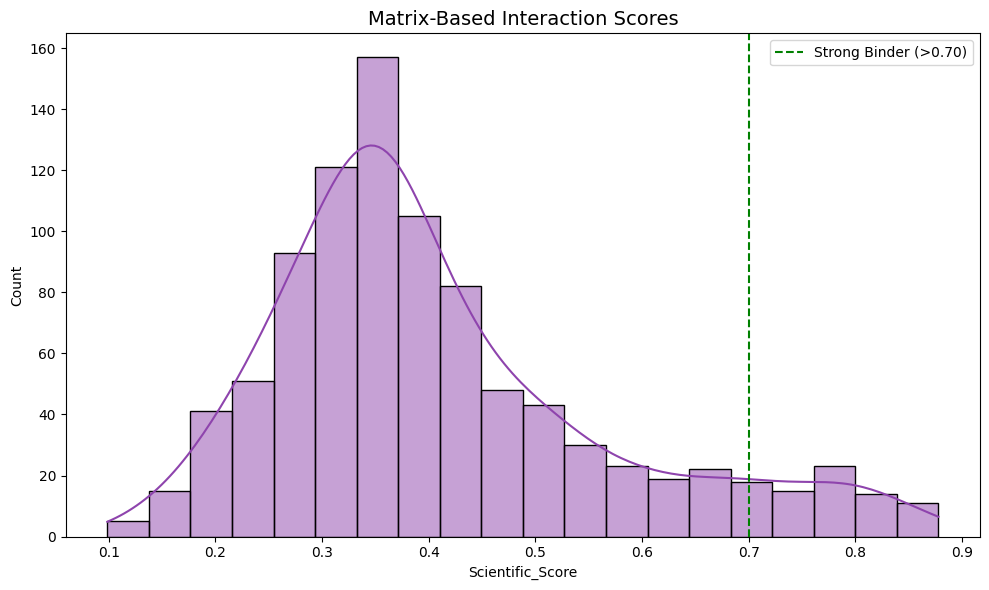


🔍 CLD18_2 ÖZEL KONTROL (Affinity_dG 0 olmamalı)
                 Sample_ID  Scientific_Score  Affinity_dG  Matrix_iPTM  Matrix_PAE
scfv_73_0_vs_cld18_2_human          0.797989      -13.815        0.580        3.73
scfv_86_5_vs_cld18_2_human          0.721738      -11.905        0.450        5.26
scfv_37_1_vs_cld18_2_human          0.683960      -12.283        0.410        5.98
scfv_83_2_vs_cld18_2_human          0.633154      -10.360        0.480        6.87
 scfv_0_4_vs_cld18_2_human          0.574243       -7.725        0.550        5.43
scfv_94_1_vs_cld18_2_human          0.531619      -13.010        0.280        8.75
scfv_73_2_vs_cld18_2_human          0.442153       -9.239        0.370        9.22
 scfv_0_2_vs_cld18_2_human          0.427945       -8.441        0.395        8.64
scfv_94_7_vs_cld18_2_human          0.424797       -9.414        0.335        9.64
scfv_39_1_vs_cld18_2_human          0.412316      -13.471        0.155       10.54
scfv_85_8_vs_cld18_2_human          0.

In [4]:
# @title 🧬 AF3 Matrix-Based Scoring Pipeline (v3.2 - CLD18.2 FIX)
# @markdown Bu hücreyi çalıştırın. CLD18_2 afinite eşleşme sorunu giderilmiştir.

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# --- AYARLAR ---
CONFIG = {
    "root_dir": "/home/ozangocmen/RFantibody/CLDN_family_combinations/outputs",
    "affinity_file": "/home/ozangocmen/RFantibody/CLDN_family_combinations/binding_affinity/off_target_prodigy.tsv",
    "output_csv": "/home/ozangocmen/RFantibody/CLDN_family_combinations/OTR_offtarget/OTR_offtarget_test1.csv",
    
    "weights": {
        "w_Matrix_iPTM": 0.40,
        "w_Matrix_PAE": 0.25,
        "w_Affinity": 0.25,
        "w_Global_pTM": 0.10
    },
    
    "sigmoid_midpoint": -9.0,
    "sigmoid_steepness": 1.0
}

# --- YENİ FONKSİYONLAR ---

def parse_af3_matrix_json(json_path):
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        ptm = data.get('ptm', 0)
        has_clash = data.get('has_clash', 0)
        frac_disordered = data.get('fraction_disordered', 0)
        ranking_score = data.get('ranking_score', 0)
        
        # Matrix iPTM
        cp_iptm = data.get('chain_pair_iptm', [])
        interaction_iptm = 0
        if cp_iptm and len(cp_iptm) >= 3:
            val1 = cp_iptm[0][2]
            val2 = cp_iptm[1][2]
            interaction_iptm = (val1 + val2) / 2.0
        else:
            interaction_iptm = data.get('iptm', 0)
        
        # Matrix PAE
        cp_pae = data.get('chain_pair_pae_min', [])
        interface_pae = 15.0
        if cp_pae and len(cp_pae) >= 3:
            val1 = cp_pae[0][2]
            val2 = cp_pae[1][2]
            interface_pae = min(val1, val2)
        
        return {
            "pTM": ptm,
            "Has_Clash": has_clash,
            "Fraction_Disordered": frac_disordered,
            "Ranking_Score": ranking_score,
            "Matrix_iPTM": interaction_iptm,
            "Matrix_PAE": interface_pae
        }
    except Exception as e:
        print(f"JSON Parse Error for {json_path}: {e}")
        return None

def normalize_affinity_sigmoid(dG, mid_point, steepness):
    if dG > -4.0: return 0.0
    return 1.0 / (1.0 + np.exp(steepness * (dG - mid_point)))

def calculate_matrix_score(row, cfg):
    w = cfg['weights']
    raw_pae = row.get('Matrix_PAE', 15.0)
    norm_pae = (12.0 - raw_pae) / (12.0 - 5.0)
    norm_pae = np.clip(norm_pae, 0, 1)
    
    dG = row.get('Affinity_dG', 0)
    term_affinity = normalize_affinity_sigmoid(dG, cfg['sigmoid_midpoint'], cfg['sigmoid_steepness'])
    
    frac_dis = row.get('Fraction_Disordered', 0)
    penalty = 0
    if frac_dis > 0.15:
        penalty = (frac_dis - 0.15) * 1.0
    
    score = (
        (w['w_Matrix_iPTM'] * row['Matrix_iPTM']) +
        (w['w_Global_pTM'] * row['pTM']) +
        (w['w_Matrix_PAE'] * norm_pae) +
        (w['w_Affinity'] * term_affinity)
    )
    score = score - penalty
    if row.get('Has_Clash', 0) > 0:
        score = 0.0
    return max(0, score)

# --- ANA AKIŞ ---
print(f"🚀 Matrix-Based Pipeline Başlatılıyor...")

results = []
folders = glob(os.path.join(CONFIG["root_dir"], "*"))

print(f"📁 Toplam {len(folders)} klasör taranıyor...")

for subdir in folders:
    if not os.path.isdir(subdir): continue
    sample_id = os.path.basename(subdir)
    summary_files = glob(os.path.join(subdir, "*summary_confidences.json"))
    
    if not summary_files: continue
    metrics = parse_af3_matrix_json(summary_files[0])
    if metrics:
        metrics['Sample_ID'] = sample_id
        results.append(metrics)

df = pd.DataFrame(results)
print(f"✅ {len(df)} AF3 modeli başarıyla okundu.")

# --- ENERJİ VERİSİ YÜKLEME VE DÜZELTME ---
if os.path.exists(CONFIG["affinity_file"]):
    print("\n🔋 Enerji verileri ekleniyor...")
    try:
        df_affinity = pd.read_csv(CONFIG["affinity_file"], sep='\t')
        df_affinity.columns = df_affinity.columns.str.strip()
        
        # Sütun isim düzeltme
        rename_map = {'Structure': 'Sample_ID', 'Affinity_kcal-mol': 'Affinity_dG', 'dG': 'Affinity_dG'}
        df_affinity.rename(columns=rename_map, inplace=True)
        
        if 'Affinity_dG' in df_affinity.columns:
            df_affinity['Affinity_dG'] = df_affinity['Affinity_dG'].astype(str).str.strip().astype(float)
        
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].astype(str).str.strip()
        
        # --- KRİTİK DÜZELTME BAŞLANGICI ---
        
        # 1. Model suffix'ini kaldır (örn: _model_model0)
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].str.replace(r'_model.*', '', regex=True)
        
        # 2. CLD18_2 Eşleşme Yaması
        # Affinity dosyasında "cld182" yazıyor ama klasörde "cld18_2" var.
        # Bu yüzden affinity dosyasındaki ismi değiştiriyoruz:
        df_affinity['Sample_ID'] = df_affinity['Sample_ID'].str.replace('cld182_human', 'cld18_2_human', regex=False)
        
        # --- KRİTİK DÜZELTME BİTİŞİ ---
        
        # Merge işlemi
        df = pd.merge(df, df_affinity[['Sample_ID', 'Affinity_dG']], on='Sample_ID', how='left')
        df['Affinity_dG'] = df['Affinity_dG'].fillna(0)
        
        # Kontrol
        cld182_check = df[df['Sample_ID'].str.contains('cld18_2')]
        matched_cld182 = cld182_check[cld182_check['Affinity_dG'] != 0]
        
        print(f"   ✅ Toplam {df['Affinity_dG'].ne(0).sum()} afinite eşleşmesi yapıldı.")
        
        if len(matched_cld182) > 0:
            print(f"   ✅ CLD18_2 Düzeltmesi BAŞARILI: {len(matched_cld182)} model afinite ile eşleşti.")
        else:
            print(f"   ⚠️ UYARI: CLD18_2 modelleri hala 0 afiniteye sahip!")

    except Exception as e:
        print(f"❌ Enerji verisi hatası: {e}")
        df['Affinity_dG'] = 0
else:
    df['Affinity_dG'] = 0

# Skorlama
print("\n🧮 Matrix-Based Score hesaplanıyor...")
df['Scientific_Score'] = df.apply(lambda row: calculate_matrix_score(row, CONFIG), axis=1)
df_sorted = df.sort_values(by="Scientific_Score", ascending=False)

# Kayıt
output_dir = os.path.dirname(CONFIG["output_csv"])
if output_dir and not os.path.exists(output_dir): os.makedirs(output_dir, exist_ok=True)
df_sorted.to_csv(CONFIG["output_csv"], index=False)
print(f"💾 Rapor: {CONFIG['output_csv']}")

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.histplot(df_sorted['Scientific_Score'], bins=20, kde=True, color='#8e44ad')
plt.axvline(0.70, color='green', linestyle='--', label='Strong Binder (>0.70)')
plt.title("Matrix-Based Interaction Scores", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# CLD18_2 Kontrol Çıktısı
print("\n" + "="*80)
print("🔍 CLD18_2 ÖZEL KONTROL (Affinity_dG 0 olmamalı)")
print("="*80)
cols = ['Sample_ID', 'Scientific_Score', 'Affinity_dG', 'Matrix_iPTM', 'Matrix_PAE']
cld18_2_models = df_sorted[df_sorted['Sample_ID'].str.contains('cld18_2', case=False)]
if len(cld18_2_models) > 0:
    print(cld18_2_models[cols].to_string(index=False))
else:
    print("⚠️  CLD18_2 modeli analizde bulunamadı!")